# 1.Setup

In [15]:
import sys
from pathlib import Path

# Thêm thư mục gốc project (cha của notebooks/) vào sys.path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import DATA_DIR, DATA_RAW_DIR, DATA_PROCESSED_DIR, DATA_FILTERED_DIR
from src.data.loader import load_dataset
from src.data.preprocessing import drop_unused_columns, encode_binary_columns, encode_ordinal_columns
from src.evaluation.visualization import heatmap, plot_distribution
from src.data.feature_engineer import engineer_features
from src.data.preprocessing import split_train_val_test 
from src.data.filter import boruta_filt

# 2. Load dataset

In [2]:
data = load_dataset(DATA_DIR/ "student_performance_dataset.csv")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 115.4 KB
None


# 3. Preprocessing

In [3]:
data_encode_bi = encode_binary_columns(data)
data_encode_bi_or = encode_ordinal_columns(data_encode_bi, "flag") #Điền -1 vào ô dữ liệu nan
print(data_encode_bi_or.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   int64  
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          1000 non-null   int64  
 6   internet_access             1000 non-null   int64  
 7   extracurricular_activities  1000 non-null   int64  
 8   part_time_job               1000 non-null   int64  
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   int64  
dtypes: float64(5), int64(7)
memory usage: 93.9 KB
None


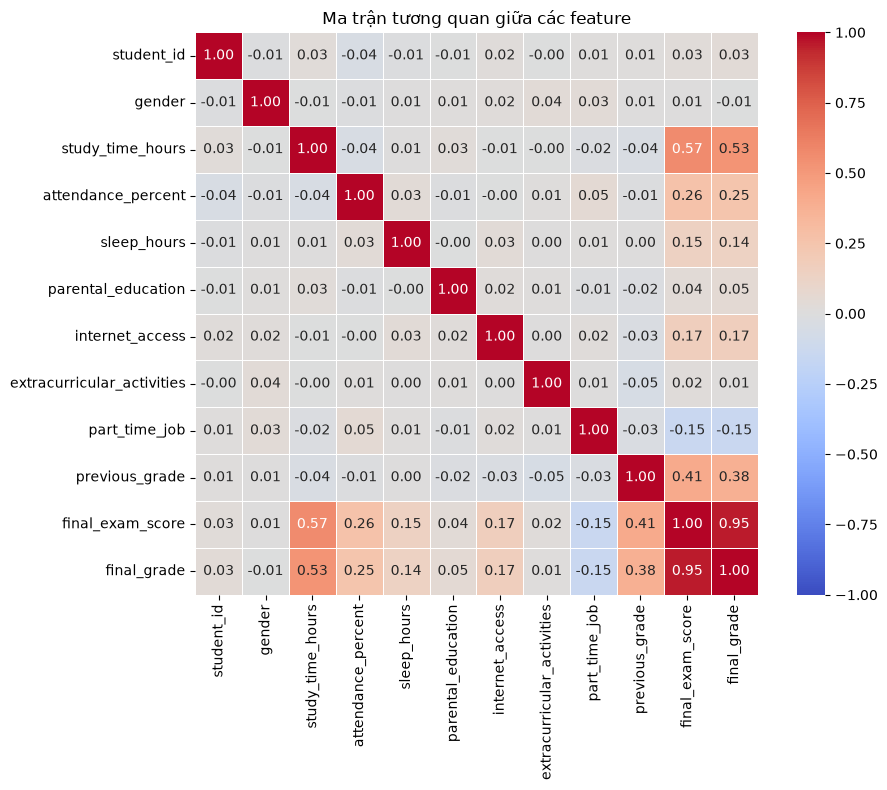

In [4]:
heatmap(data_encode_bi_or)

=> Drop final_exam vì nguy cơ cao là Data leak

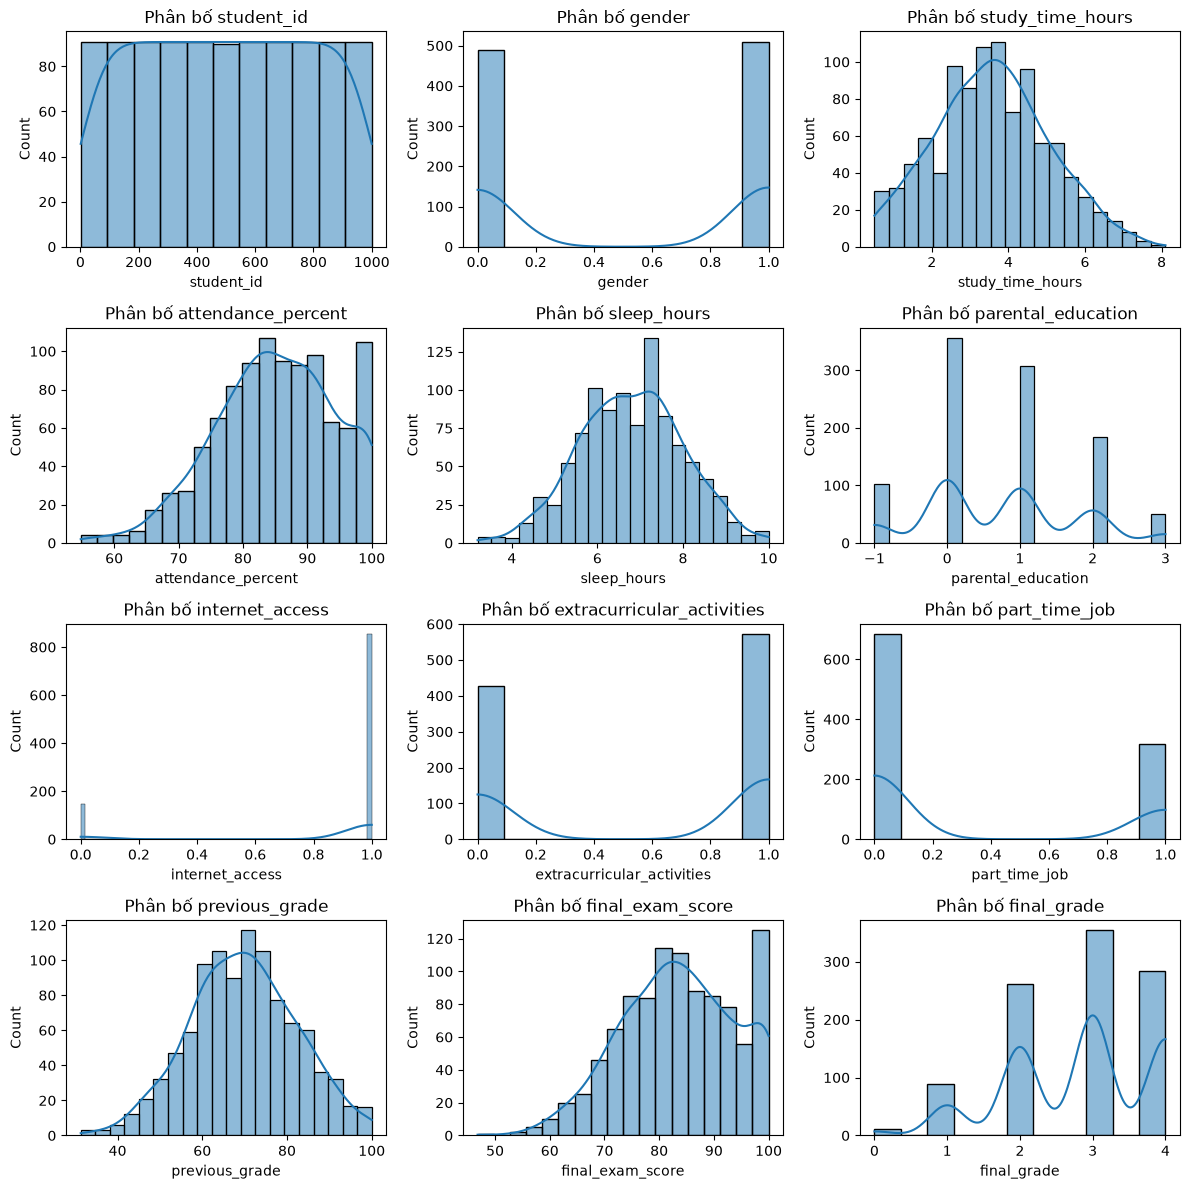

In [5]:
plot_distribution(data_encode_bi_or)

In [6]:
unused_cols = ["final_exam_score","student_id"]
data_final = drop_unused_columns(data_encode_bi_or, unused_cols)
print(data_final.info())


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      1000 non-null   int64  
 1   study_time_hours            1000 non-null   float64
 2   attendance_percent          1000 non-null   float64
 3   sleep_hours                 1000 non-null   float64
 4   parental_education          1000 non-null   int64  
 5   internet_access             1000 non-null   int64  
 6   extracurricular_activities  1000 non-null   int64  
 7   part_time_job               1000 non-null   int64  
 8   previous_grade              1000 non-null   float64
 9   final_grade                 1000 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 78.3 KB
None


In [7]:
fe_data = engineer_features(data_final)
print(fe_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   int64   
 1   study_time_hours             1000 non-null   float64 
 2   attendance_percent           1000 non-null   float64 
 3   sleep_hours                  1000 non-null   float64 
 4   parental_education           1000 non-null   int64   
 5   internet_access              1000 non-null   int64   
 6   extracurricular_activities   1000 non-null   int64   
 7   part_time_job                1000 non-null   int64   
 8   previous_grade               1000 non-null   float64 
 9   final_grade                  1000 non-null   int64   
 10  study_efficiency             1000 non-null   float64 
 11  study_time_x_previous_grade  1000 non-null   float64 
 12  attendance_x_sleep           1000 non-null   float64 
 13  sleep_hours_gro

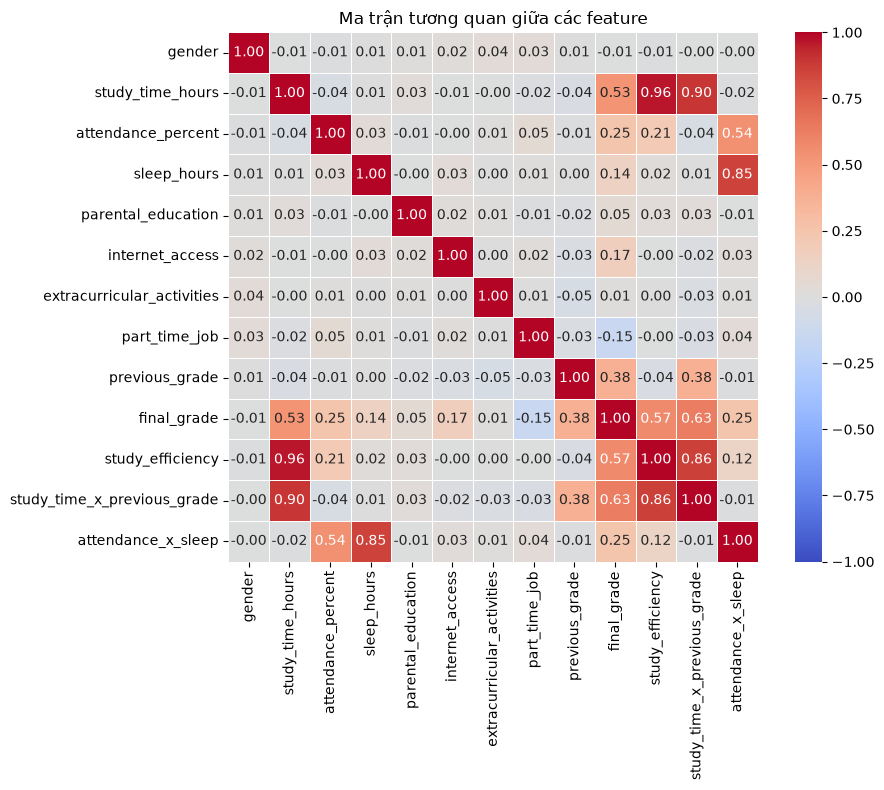

In [8]:
heatmap(fe_data)

# 4. Dimension reduction

In [9]:
data_filtered = boruta_filt(fe_data)
print(data_filtered.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   study_time_hours             1000 non-null   float64
 1   attendance_percent           1000 non-null   float64
 2   previous_grade               1000 non-null   float64
 3   study_efficiency             1000 non-null   float64
 4   study_time_x_previous_grade  1000 non-null   float64
 5   attendance_x_sleep           1000 non-null   float64
 6   final_grade                  1000 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 54.8 KB
None


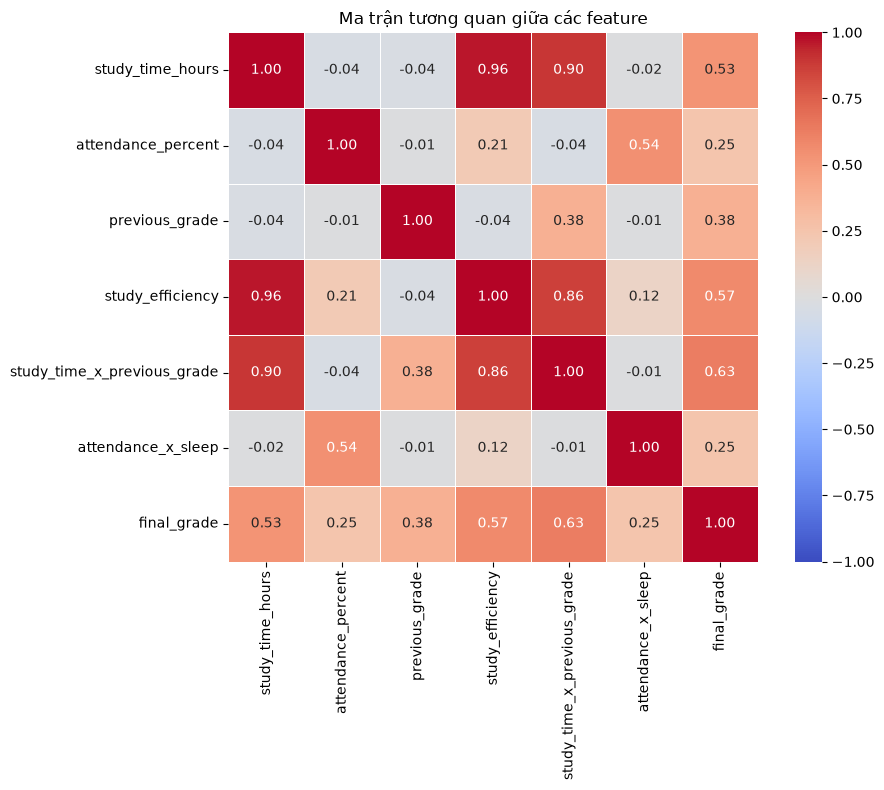

In [10]:
heatmap(data_filtered)

In [11]:
#save data khi chưa thêm các đặc trưng
split_train_val_test(
    df=data_final, 
    folder_path= DATA_RAW_DIR
    )

Đã lưu 700 dòng train (70.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\raw\train.csv
Đã lưu 100 dòng val (10.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\raw\val.csv
Đã lưu 200 dòng test (20.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\raw\test.csv


In [12]:
#save data khi đã thêm các đặc trưng
split_train_val_test(
    df=fe_data, 
    folder_path= DATA_PROCESSED_DIR
    )

Đã lưu 700 dòng train (70.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\processed\train.csv
Đã lưu 100 dòng val (10.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\processed\val.csv
Đã lưu 200 dòng test (20.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\processed\test.csv


In [16]:
#save data khi đã giảm chiều
split_train_val_test(
    df=data_filtered, 
    folder_path= DATA_FILTERED_DIR
    )

Đã lưu 700 dòng train (70.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\filtered\train.csv
Đã lưu 100 dòng val (10.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\filtered\val.csv
Đã lưu 200 dòng test (20.0%) vào: D:\HCMUT\AIO\Project\Idontknowyet\data\filtered\test.csv
